## Domain detector: A first approach using Random Forest

As of this wirting, we already have train some models for multi class classification in 12 particular sub white dwarf categories. In the following notebok, we will 
try to train a random forest algorithm in order to try and detect when we are outside of this classes, using the discarded classes of 'STAR; 'EXGAL', 'UNCLASS'.
We will also be excluding from the domain the 'DUNNO' class, for the moment, but i think it is not entirely clear if this cases should be examined or not.

Our algorithm is in a sense limited by our data, and we will probably need more data if our input data contains some other strange elements... but for now, let's use the data available.

We can use the functions available in our source code to make loading our data easier. The way i currently use for doing so in a jupyter notebook is:

In [1]:
import sys
import os
from pathlib import Path
sys.path.append(os.path.abspath('..'))
sys.path.append(os.path.abspath('../src'))
import src.data.make_dataset as mkd

In [2]:
current_dir =  Path(globals()['_dh'][0])
try:
    os.mkdir(os.path.join(current_dir, '1.0-jrb-domain-detector'))
except:
    print("Failed to create folder. Perhaps the folder already exists, or there's a permissions issue.")

Failed to create folder. Perhaps the folder already exists, or there's a permissions issue.


We can simply load the interim dataset which has been cleaned already, or clean it ourselves (note thats this requires running make_dataset.py, which as the time of writing will do more than only cleaning the labels, or we could also import the clean labels function and reproduce this process ourselves if we don't want to run this script).

In [3]:
import pandas as pd
from pathlib import Path

project_dir =  Path(globals()['_dh'][0]).parent
file_path =  'data/interim/clean_labels.csv'


clean_labels_df = pd.read_csv(os.path.join(project_dir, file_path))
clean_labels_df

,Classification,DB ID,Data Quality,File Name,MJD,Target ID
0,WDA,21899,OK,spec-15249-59265-04601916346-21899.png,59265,4601916346
1,sdX,23360,BLEND,spec-15301-59338-04602344336-23360.png,59338,4602344336
2,WDA,18900,SNR,spec-15113-59217-04538755416-18900.png,59217,4538755416
3,WDA,18575,OK,spec-15086-59267-04474143209-18575.png,59267,4474143209
4,WD,20528,SNR,spec-15198-59269-04351438385-20528.png,59269,4351438385
...,...,...,...,...,...,...
35248,WDA,15895,SNR,spec-15011-59222-04399876473-15895.png,59222,4399876473
35249,WDA,20605,OK,spec-15200-59324-04589320996-20605.png,59324,4589320996
35250,WDA,19388,OK,spec-15193-59243-04594923329-19388.png,59243,4594923329
35251,DUNNO,19161,SNR,spec-15121-59212-04342114705-19161.png,59212,4342114705


We will modify our dataframe with the target id, mjd and we'll replace the classification for either a 1 or a 0, if the class is of interest or not.

In [4]:
# from bleach import clean
# from inflection import underscore
import numpy as np

undesired_classes = ['DUNNO', 'UNCLASS', 'STAR', 'EXGAL']

label_series = clean_labels_df['Classification'].apply(lambda i: 0 if i in undesired_classes else 1)
clean_labels_df['Classification'] = label_series

In [5]:
clean_labels_df

,Classification,DB ID,Data Quality,File Name,MJD,Target ID
0,1,21899,OK,spec-15249-59265-04601916346-21899.png,59265,4601916346
1,1,23360,BLEND,spec-15301-59338-04602344336-23360.png,59338,4602344336
2,1,18900,SNR,spec-15113-59217-04538755416-18900.png,59217,4538755416
3,1,18575,OK,spec-15086-59267-04474143209-18575.png,59267,4474143209
4,1,20528,SNR,spec-15198-59269-04351438385-20528.png,59269,4351438385
...,...,...,...,...,...,...
35248,1,15895,SNR,spec-15011-59222-04399876473-15895.png,59222,4399876473
35249,1,20605,OK,spec-15200-59324-04589320996-20605.png,59324,4589320996
35250,1,19388,OK,spec-15193-59243-04594923329-19388.png,59243,4594923329
35251,0,19161,SNR,spec-15121-59212-04342114705-19161.png,59212,4342114705


To be coherent with the ML approach of the current models, will select one label per target id based on the most voted criterion. We will use a modified version of the label processing fucntion from make_dataset.py script.

In [6]:
def label_preprocess_dom(labels_df, data_augmentation=False):
    # Removing observations with data quality issues:

    labels_df.drop(labels_df[labels_df['Data Quality'] != 'OK'].index, inplace = True)

    # Selecting labels for each target id:
    parsed_df = pd.DataFrame()

    for object_id in labels_df['Target ID'].unique():
        mode_class = labels_df.loc[labels_df['Target ID'] == object_id]['Classification'].mode().to_list()[0]
        if data_augmentation:
            parsed_df = parsed_df.append(labels_df.loc[(labels_df['Classification'] == mode_class) & (labels_df['Target ID'] == object_id)])
        else:
            parsed_df = parsed_df.append(labels_df.loc[(labels_df['Classification'] == mode_class) & (labels_df['Target ID'] == object_id)].iloc[0])
    parsed_df = parsed_df.astype({"DB ID": 'int64', "MJD": 'int64', "Target ID" : 'int64'})
    parsed_df.reset_index(inplace=True)

    return parsed_df

In [7]:
parsed_df = label_preprocess_dom(clean_labels_df)
parsed_df

,index,Classification,DB ID,Data Quality,File Name,MJD,Target ID
0,0,1.0,21899,OK,spec-15249-59265-04601916346-21899.png,59265,4601916346
1,3,1.0,18575,OK,spec-15086-59267-04474143209-18575.png,59267,4474143209
2,5,1.0,22243,OK,spec-15266-59306-04592699543-22243.png,59306,4592699543
3,6,1.0,19555,OK,spec-15165-59202-04545012720-19555.png,59202,4545012720
4,7,1.0,20892,OK,spec-15221-59245-04306649216-20892.png,59245,4306649216
...,...,...,...,...,...,...,...
8108,35209,1.0,25029,OK,spec-15346-59300-05208867797-25029.png,59300,5208867797
8109,35211,1.0,17158,OK,spec-15034-59165-04382235429-17158.png,59165,4382235429
8110,35225,0.0,20417,OK,spec-15288-59294-04552859261-20417.png,59294,4552859261
8111,35226,0.0,25989,OK,spec-15370-59338-04347784790-25989.png,59338,4347784790


We can now see how many labels we have for our domain detector.

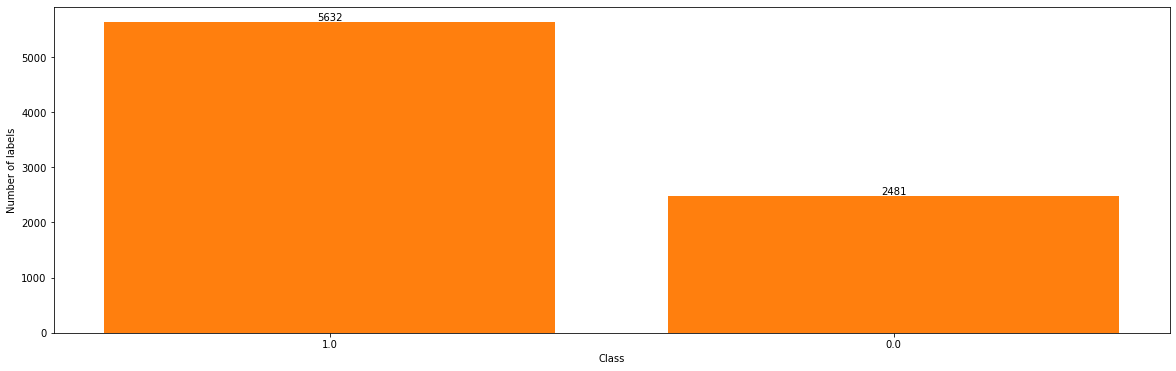

In [8]:
from collections import Counter
import matplotlib.pyplot as plt


# Plot bar graph of labels

counter = Counter(parsed_df['Classification'])
star_class = counter.keys()
star_counts = counter.values()

indexes = np.arange(len(star_class))
width = 0.7

fig, ax = plt.subplots(figsize=(20,6))

ax.bar(indexes, star_counts, width)
bars = ax.bar(indexes, star_counts)
ax.bar_label(bars)

plt.xlabel('Class')
plt.ylabel('Number of labels')
plt.xticks(indexes, labels=star_class)
plt.show()

We will use the function from the make_dataset.py script to match available dat files to file names in our dataframe.

In [9]:
sdss_datfiles_path = os.path.join(project_dir,  r'data\raw\sdss_dat_files')
spectrum_match_df = mkd.match_dat_files(parsed_df, sdss_datfiles_path)

In [10]:
spectrum_match_df

,filename,classID
0,cb_uvex4\SDSSJ121828.50+300201.3_15249-59265-0...,1.0
1,wd\SDSSJ070928.42-115148.7_15086-59267-0068_44...,1.0
2,wd\SDSSJ092633.22+031704.7_15266-59306-0129_45...,1.0
3,wd\SDSSJ084230.03+014543.0_15165-59202-0055_45...,1.0
4,wd\SDSSJ031251.58+530140.4_15221-59245-0050_43...,1.0
...,...,...
8097,cb_gaiagalex\SDSSJ180328.74+125336.5_15346-593...,1.0
8098,wd\SDSSJ234641.07+005519.9_15034-59165-0447_43...,1.0
8099,cb_uvex2\SDSSJ061822.95+413145.7_15288-59294-0...,0.0
8100,cb_gaiagalex\SDSSJ172450.01+775556.0_15370-593...,0.0


We can also use our source code function to build features for our test, train and validation sets.

In [11]:
import src.features.build_features as bfs
train_set, test_set, valid_set = bfs.make_stratified_sets(spectrum_match_df, train_set_size=0.6, validation_test_split=0.5)

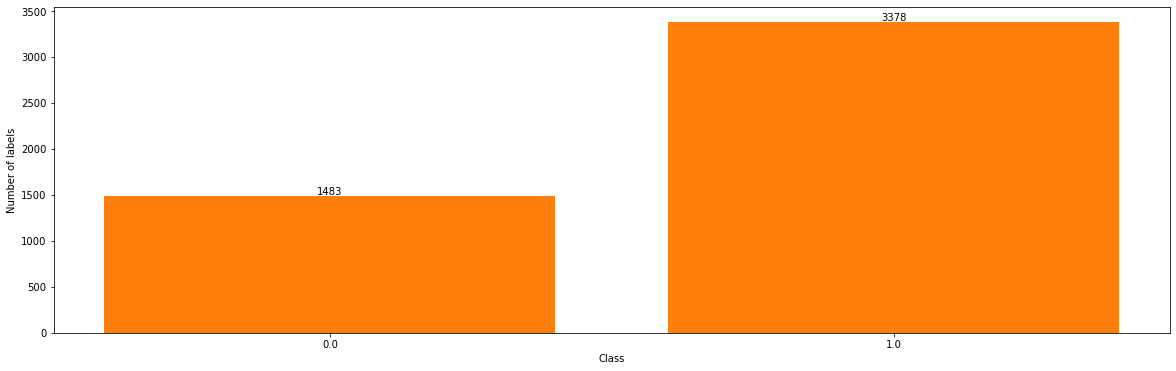

In [12]:
# Plot bar graph of labels

counter = Counter(train_set['classID'])
star_class = counter.keys()
star_counts = counter.values()

indexes = np.arange(len(star_class))
width = 0.7

fig, ax = plt.subplots(figsize=(20,6))

ax.bar(indexes, star_counts, width)
bars = ax.bar(indexes, star_counts)
ax.bar_label(bars)

plt.xlabel('Class')
plt.ylabel('Number of labels')
plt.xticks(indexes, labels=star_class)
plt.show()

## Build Features

We can now use our spectrum dataframe of available dat files to build our dataframe.

In [13]:
# Creating spectrum numpy arrays from train, validation and test sets
# Spectrums with NaN values will be removed from the imput dataframes (e.g, test_set dataframe)

sdss_data_path = os.path.join(project_dir, r'data\raw\sdss_dat_files')

test_spectrum_matrix = bfs.data_processing_and_loading(sdss_data_path, test_set, first_bin=298, last_bin=-600)
train_spectrum_matrix = bfs.data_processing_and_loading(sdss_data_path, train_set, first_bin=298, last_bin=-600)
valid_spectrum_matrix = bfs.data_processing_and_loading(sdss_data_path, valid_set, first_bin=298, last_bin=-600)

In [14]:
save_folder = os.path.join(current_dir, '1.0-jrb-domain-detector')

np.save(os.path.join(save_folder, 'domv1_train_spectrum_matrix.npy'), train_spectrum_matrix)
np.save(os.path.join(save_folder,'domv1_test_spectrum_matrix.npy'), test_spectrum_matrix)
np.save(os.path.join(save_folder,'domv1_valid_spectrum_matrix.npy'), valid_spectrum_matrix)

For our labels, we just need a numpy series

In [15]:
valid_set

,filename,classID
3020,cb_uvex2\SDSSJ085322.69+523503.3_15174-59232-0...,1.0
1496,wd\SDSSJ074024.08+202936.8_15195-59238-0382_45...,1.0
3624,cb_uvex2\SDSSJ165627.65+354451.1_15310-59315-0...,0.0
7655,wd\SDSSJ051837.65+480452.4_15121-59206-0128_43...,1.0
6835,wd\SDSSJ185042.38+380424.2_15332-59305-0230_53...,1.0
...,...,...
3799,cb_uvex2\SDSSJ161607.81+632601.8_15347-59301-0...,1.0
7966,cb_uvex1\SDSSJ163239.71-005809.1_15275-59337-0...,0.0
1031,cb_uvex2\SDSSJ234906.10+010021.9_15034-59165-0...,1.0
3280,cb_uvex4\SDSSJ092609.70-003134.2_15267-59308-0...,1.0


In [16]:
train_spectrum_matrix.shape, valid_spectrum_matrix.shape

((4845, 3750), (1617, 3750))

In [17]:
train_labels_np = train_set['classID'].to_numpy()
len(train_labels_np)

4845

In [18]:
valid_labels_np = valid_set['classID'].to_numpy()
len(valid_labels_np)

1617

In [19]:
test_labels_np = test_set['classID'].to_numpy()
len(test_labels_np)

1616

## Making a random forest model.

First we will oversample our training data. As we will perform K fold cross validation we can merge de validation and training sets.

In [20]:
train_X = np.concatenate([train_spectrum_matrix, valid_spectrum_matrix])
train_Y = np.concatenate([train_labels_np, valid_labels_np])

In [21]:
train_X.shape, train_Y.shape

((6462, 3750), (6462,))

In [22]:
# you can run pip install imblearn to get the imbalanced learn module.
# Resampling the majority dataset in order to balance the set.

from imblearn.over_sampling import RandomOverSampler
over_sampler = RandomOverSampler(random_state=40, sampling_strategy='not majority')
X_over, Y_over = over_sampler.fit_resample(train_X, train_Y)

In [23]:
# Import the model we are using
# from sklearn.ensemble import RandomForestRegressor# Instantiate model with 1000 decision trees
# rf = RandomForestRegressor(n_estimators = 1000, random_state = 42)# Train the model on training data
# rf.fit(train_spectrum_matrix, train_labels_np)

We will now proceed with the training of our model.

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import validation_curve

# Create range of values for parameter
param_range = np.arange(1, 50, 2)

# Calculate accuracy on training and test set using range of parameter values
train_scores, test_scores = validation_curve(RandomForestClassifier(criterion='log_loss'), 
                                             X_over, 
                                             Y_over, 
                                             param_name="n_estimators", 
                                             param_range=param_range,
                                             cv=3, 
                                             scoring="accuracy", 
                                             n_jobs=-1)


# Calculate mean and standard deviation for training set scores
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)

# Calculate mean and standard deviation for test set scores
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

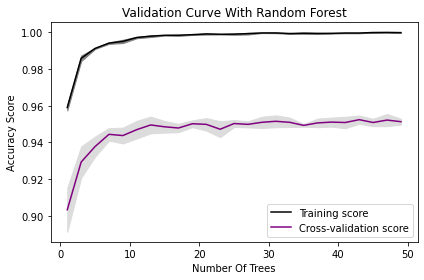

In [25]:
# Plot mean accuracy scores for training and test sets
plt.plot(param_range, train_mean, label="Training score", color="black")
plt.plot(param_range, test_mean, label="Cross-validation score", color="purple")

# Plot accurancy bands for training and test sets
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, color="gray")
plt.fill_between(param_range, test_mean - test_std, test_mean + test_std, color="gainsboro")

# Create plot
plt.title("Validation Curve With Random Forest")
plt.xlabel("Number Of Trees")
plt.ylabel("Accuracy Score")
plt.tight_layout()
plt.legend(loc="best")
plt.show()


There seems to be around 95% accuracyfor this classifier. Let's train it and save it.

In [30]:
clf=RandomForestClassifier(criterion='log_loss', n_estimators=14)
clf.fit(X_over, Y_over)

RandomForestClassifier(criterion='log_loss', n_estimators=14)

In [31]:
preds = clf.predict(test_spectrum_matrix)
print(clf.score(test_spectrum_matrix, test_labels_np))

0.9108910891089109


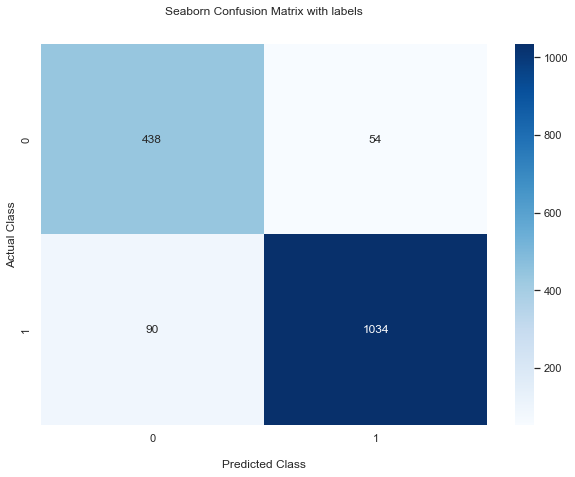

In [32]:
# Visualize confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

CM = confusion_matrix(test_labels_np, preds)

# Visualize it as a heatmap
sns.set(rc = {'figure.figsize':(10,7)})
ax = sns.heatmap(CM, annot=True, fmt='.4g', cmap='Blues')

ax.set_title('Seaborn Confusion Matrix with labels\n\n')
ax.set_xlabel('\nPredicted Class')
ax.set_ylabel('Actual Class')

## Display the visualization of the Confusion Matrix.
plt.show()


In [33]:
import joblib


joblib.dump(clf, os.path.join(current_dir, "1.0-jrb-domain-detector/rf_dom_v1.joblib"))
# load, no need to initialize the loaded_rf
# loaded_rf = joblib.load("./random_forest.joblib")

['c:\\Users\\mafalsa\\OneDrive - Universidad Técnica Federico Santa María\\Documentos\\GitHub\\ML_NPF\\notebooks\\1.0-jrb-domain-detector/rf_dom_v1.joblib']